# Scenario Comparison Analysis

In [3]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [5]:
home = "/home/lucakristin/Desktop/my_pypsa"
base_folder = "germany_base_"
cluster = "450" 

### Create scenario network 

In [14]:
wind_opt = "windy"  # or "not-windy" or "wind-variability"
scenario_name = "germany_scenario1"  # or "scenario2", "scenario3", etc

In [29]:
!python ../create_germany_scenario.py  --home {home} --base-folder {base_folder} --cluster {cluster} --wind-condition {wind_opt} --capacity-scenario {scenario_name}

[Tue May  5 15:15:39 2026] Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/results/germany_base_windy/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
[Tue May  5 15:15:41 2026] Loading scenario configuration from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario1.json
[Tue May  5 15:15:41 2026] Modifying generator capacities for scenario 'germany_scenario1'.
Removing capacity from zero-share carriers ['coal', 'lignite', 'OCGT', 'oil', 'offwind-dc']: 51606.07 MW
Current total capacity of selected carriers: 175224.75 MW
Scale capacity of selected carriers by 1.000 to 175224.75 MW
solar: modified from 48771.25 MW to 44244.21 MW
onwind: modified from 39140.61 MW to 36599.27 MW
offwind-ac: modified from 11163.74 MW to 44244.21 MW
Carrier 

## 3. Load unsolved networks to see modifications

In [30]:
base_config_name = f"{base_folder}{wind_opt}"
scenario_config_name = f"{scenario_name}_{wind_opt}"
print(f"Base Config Name: {base_config_name}")
print(f"Scenario Config Name: {scenario_config_name}")

Base Config Name: germany_base_windy
Scenario Config Name: germany_scenario1_windy


In [31]:
# Load the unsolved base network to compare initial capacities
base_network_path_unsolved = f"{home}/pypsa-eur/resources/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base_unsolved = pypsa.Network(base_network_path_unsolved)

# --- Load Scenario Network ---
scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved, name="Scenario Network")

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


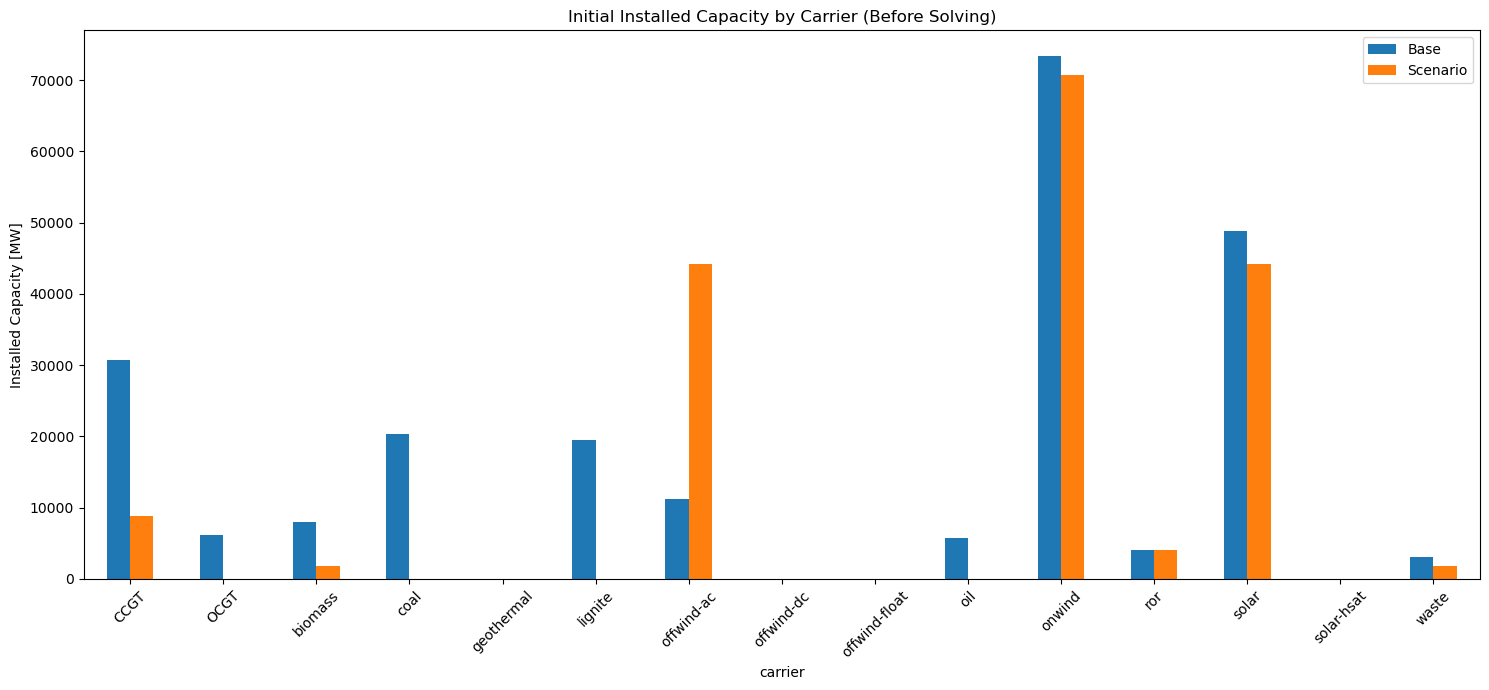

In [33]:
### plot initial capacities by carrier for both networks (before solving)
p_nom_base = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
p_nom_scenario = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()

df = pd.DataFrame({
    "Base": p_nom_base,
    "Scenario": p_nom_scenario
}).dropna()

df.plot(kind="bar", figsize=(15, 7), rot=45)
plt.ylabel("Installed Capacity [MW]")
plt.title("Initial Installed Capacity by Carrier (Before Solving)")
plt.tight_layout()
plt.show()

In [34]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_base_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(base_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_base_windy
Capacity share by carrier (% of total installed generator capacity):
carrier
onwind           31.77%
solar            21.13%
CCGT             13.33%
coal              8.82%
lignite           8.43%
offwind-ac        4.84%
biomass           3.47%
OCGT              2.65%
oil               2.46%
ror               1.74%
waste             1.35%
geothermal        0.01%
offwind-float      0.0%
offwind-dc         0.0%
solar-hsat         0.0%
Name: p_nom, dtype: object


In [35]:
# Capacity share by generator carrier for the scenario network
carrier_capacity = n_scenario_unsolved.generators.groupby("carrier").p_nom.sum()
carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
print(scenario_config_name)
print("Capacity share by carrier (% of total installed generator capacity):")
print(carrier_capacity_pct.sort_values(ascending=False).round(2).astype(str) + "%")

germany_scenario1_windy
Capacity share by carrier (% of total installed generator capacity):
carrier
onwind           40.29%
solar            25.18%
offwind-ac       25.18%
CCGT              5.04%
ror               2.28%
waste             1.01%
biomass           1.01%
geothermal        0.01%
lignite            0.0%
OCGT               0.0%
coal               0.0%
oil                0.0%
offwind-float      0.0%
offwind-dc         0.0%
solar-hsat         0.0%
Name: p_nom, dtype: object


---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [200]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_config_name}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_config_name}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario_1.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [226]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
